<a href="https://colab.research.google.com/github/iarabertopena/active-learning-for-multi-label-streams/blob/main/03_active_learning_multi_label_streams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa
psutil
rarfile

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt

### Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import rarfile
import psutil
import time
import math
import os

from capymoa.classifier import (
    AdaptiveRandomForestClassifier,
    HoeffdingAdaptiveTree,
    StreamingRandomPatches
)

from capymoa.evaluation import prequential_evaluation

from capymoa.drift.detectors import ADWIN

from capymoa.stream import NumpyStream
from capymoa.stream import Schema

from IPython.utils import process
from collections import deque
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.metrics import (hamming_loss, f1_score)

### Datasets

In [5]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Flags.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "flags.arff")

print(dataset_path)

Mounted at /content/drive
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/flags/flags.arff


In [6]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Emotions.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "emotions.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/emotions/emotions.arff


In [7]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Scene.zip"

extract_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene"

with zipfile.ZipFile(base_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "scene.arff")

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/scene/scene.arff


In [8]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Yeast.arff"

print(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/Yeast.arff


In [9]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPGrad.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/SynHPInc.arff"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
base_path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos_stream/"

dataset_paths = {
    "flags": base_path + "flags/flags.arff",
    "emotions": base_path + "emotions/emotions.arff",
    "scene": base_path + "scene/scene.arff",
    "birds": base_path + "birds/birds.arff",
    "yeast": base_path + "Yeast.arff",
    #"synhpgrad": base_path + "SynHPGrad.arff",
    #"synhpinc": base_path + "SynHPInc.arff"
}

n_labels_dict = {
    "flags": 7,
    "emotions": 6,
    "scene": 6,
    "birds": 19,
    "yeast": 14,
    #"synhpgrad": 8,
    #"synhpinc": 8
}

In [12]:
def load_multilabel_dataset(dataset_name):

    dataset_path = dataset_paths[dataset_name]

    n_labels = n_labels_dict[dataset_name]

    # carregar arff
    data, meta = arff.loadarff(dataset_path)

    # dataframe
    df = pd.DataFrame(data)

    # converter bytes -> string/int
    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode('utf-8')
                if isinstance(x, bytes)
                else x
            )

    # converter tudo para float
    df = df.astype(float)

    # dataset sintéticos: labels no começo
    if dataset_name in ["synhpgrad", "synhpinc", "yeast"]:

        Y = df.iloc[:, :n_labels].values.astype(int)

        X = df.iloc[:, n_labels:].values

    # datasets reais: labels no final
    else:

        X = df.iloc[:, :-n_labels].values

        Y = df.iloc[:, -n_labels:].values.astype(int)

    return X, Y

### Métricas de avaliação

In [13]:
# métricas
metrics = {
    "f1": "Macro-F1",
    "hamming": "Hamming Loss",
    "exact_match": "Exact Match"
}

### Binary Relevance

In [34]:
class BinaryRelevance:

    def __init__(self, model_class, n_labels, schema):

        self.n_labels = n_labels
        self.models = []

        for _ in range(n_labels):

            model = model_class(
                schema=schema
            )

            self.models.append(model)

    # previsão
    def predict(self, x):

        predictions = []

        temp_stream = NumpyStream(
             X=np.array([x]),
             y=np.array([0])
          )

        instance = temp_stream.next_instance()

        for model in self.models:

            pred = model.predict(instance)

            if pred is None:
                pred = 0

            predictions.append(int(pred))

        return np.array(predictions)

    # probabilidades
    def predict_proba(self, x):

        probabilities = []

        temp_stream = NumpyStream(
            X=np.array([x]),
            y=np.array([0])
        )

        instance = temp_stream.next_instance()

        for model in self.models:

            proba = model.predict_proba(instance)

            if proba is None:
                proba = np.array([0.5, 0.5])

            probabilities.append(proba)

        return probabilities

    # treino
    def train(self, x, y, label_mask=None):

        # se não tem máscara, assume que todos os rótulos estão disponíveis
        if label_mask is None:
            label_mask = [True] * self.n_labels

        if len(label_mask) != self.n_labels:
            raise ValueError("label_mask deve ter tamanho n_labels")

        for j, model in enumerate(self.models):

            # treina apenas os rótulos observados
            if label_mask[j]:

              temp_stream = NumpyStream(
                  X=np.array([x]),
                  y=np.array([y[j]])
              )

              instance = temp_stream.next_instance()

              model.train(instance)

### Active Learning

In [15]:
class ActiveLearningStrategy:

    def __init__(self):

        self.total_seen = 0
        self.total_queried = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):
        raise NotImplementedError

#### Random

In [16]:
class RandomSampling(ActiveLearningStrategy):

    def __init__(self, budget):

        super().__init__()

        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        if np.random.rand() < self.budget:

            self.total_queried += 1

            return True

        return False

#### Uncertainty sampling

In [17]:
def compute_uncertainty(probabilities):
    uncertainties = []

    for proba in probabilities:
        # Least Confidence
        confidence = np.max(proba)
        uncertainty = 1 - confidence
        uncertainties.append(uncertainty)

    #result = np.mean(uncertainties)
    result = np.max(uncertainties)

    return result

In [18]:
class UncertaintySampling(ActiveLearningStrategy):

    def __init__(self, threshold, budget):

        super().__init__()

        self.threshold = threshold
        self.budget = budget

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        #print(probabilities)
        uncertainty = compute_uncertainty(probabilities)

        if uncertainty >= self.threshold:

            self.total_queried += 1

            return True

        return False

#### Query-by-committee

In [19]:
committee_models = [
    AdaptiveRandomForestClassifier,
    HoeffdingAdaptiveTree,
    StreamingRandomPatches
]

In [20]:
class Committee:

    def __init__(self, model_classes, n_labels, schema):

        self.models = []

        for model_class in model_classes:

            br_model = BinaryRelevance(
                model_class=model_class,
                n_labels=n_labels,
                schema=schema
            )

            self.models.append(br_model)

    def predict_all(self, x):

        predictions = []

        for model in self.models:

            predictions.append(
                model.predict(x)
            )

        return np.array(predictions)

    def predict_proba_all(self, x):

        probabilities = []

        for model in self.models:

            probabilities.append(
                model.predict_proba(x)
            )

        return probabilities

    def train(self, x, y, label_mask=None):

        for model in self.models:

            model.train(x, y, label_mask=label_mask)

In [21]:
def compute_vote_entropy(predictions):

    entropies = []

    n_members = predictions.shape[0]

    for label in range(predictions.shape[1]):

        votes = predictions[:, label]

        counts = np.bincount(
            votes,
            minlength=2
        )

        probs = counts / n_members

        probs = probs[probs > 0]

        entropy = -np.sum(
            probs * np.log2(probs)
        )

        entropies.append(entropy)

    return np.mean(entropies)

In [22]:
class QueryByCommittee(ActiveLearningStrategy):

    def __init__(self, threshold, budget, warmup):

        super().__init__()

        self.threshold = threshold
        self.budget = budget
        self.warmup = warmup

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        # orçamento esgotado
        if self.total_queried >= self.budget_limit:
            return False

        # warm-up
        if self.total_seen <= self.warmup:

            self.total_queried += 1
            return True

        if committee_predictions is None:
            return False

        disagreement = compute_vote_entropy(committee_predictions)

        #print(f"Seen={self.total_seen} | "f"Disagreement={disagreement:.4f}")

        if disagreement >= self.threshold:

            self.total_queried += 1
            return True

        return False

#### Bounds

##### Lower Bound -> sem consultas (budget = 0%)

In [23]:
class NoQuery(ActiveLearningStrategy):

    def __init__(self):

        super().__init__()

        self.budget = 0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1

        return False

##### Upper Bound -> aprendizado totalmente supervisionado (budget = 100%)

In [24]:
class FullSupervision(ActiveLearningStrategy):

    def __init__(self):

        super().__init__()

        self.budget = 1.0

    def query(
        self,
        x=None,
        y_true=None,
        y_pred=None,
        probabilities=None,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.total_seen += 1
        self.total_queried += 1

        return True

### Pool-based Active Learning

In [25]:
class Pool:

    def __init__(self, pool_size):

        self.pool_size = pool_size
        self.instances = []

    def add(
        self,
        x,
        y,
        y_pred,
        probabilities,
        committee_predictions=None,
        committee_probabilities=None
    ):

        self.instances.append({
            "x": x,
            "y": y,
            "y_pred": y_pred,
            "probabilities": probabilities,
            "committee_predictions": committee_predictions,
            "committee_probabilities": committee_probabilities
        })

    def is_full(self):

        return len(self.instances) >= self.pool_size

    def clear(self):

        self.instances = []

    def __len__(self):

        return len(self.instances)

In [26]:
class PoolBasedStrategy(ActiveLearningStrategy):

    def __init__(self, budget):

        super().__init__()

        self.budget = budget

    def query_pool(self, pool):

        raise NotImplementedError

#### Random

In [27]:
class PoolRandomSampling(PoolBasedStrategy):

    def __init__(self, budget):

        super().__init__(budget)

    def query_pool(self, pool):

        remaining_budget = self.budget_limit - self.total_queried

        if remaining_budget <= 0:
            return []

        k = min(
            self.pool_budget,
            remaining_budget,
            len(pool.instances)
        )

        indices = np.random.choice(
            len(pool.instances),
            size=k,
            replace=False
        )

        self.total_seen += len(pool.instances)
        self.total_queried += len(indices)

        return indices

#### Uncertainty sampling

In [28]:
class PoolUncertaintySampling(PoolBasedStrategy):

    def __init__(self, budget):

        super().__init__(budget)

    def query_pool(self, pool):

        remaining_budget = self.budget_limit - self.total_queried

        if remaining_budget <= 0:
            return []

        scores = []

        for inst in pool.instances:

            u = compute_uncertainty(
                inst["probabilities"]
            )

            scores.append(u)

        order = np.argsort(scores)[::-1]

        k = min(
            self.pool_budget,
            remaining_budget,
            len(order)
        )

        selected = order[:k]

        self.total_seen += len(pool.instances)
        self.total_queried += len(selected)

        return selected

#### Query-by-committee

In [29]:
class PoolQueryByCommittee(PoolBasedStrategy):

    def __init__(self, budget):

        super().__init__(budget)

    def query_pool(self, pool):

        remaining_budget = (
            self.budget_limit - self.total_queried
        )

        if remaining_budget <= 0:
            return []

        scores = []

        for inst in pool.instances:

            disagreement = compute_vote_entropy(
                inst["committee_predictions"]
            )

            scores.append(disagreement)

        # ordenar da maior discordância para a menor
        order = np.argsort(scores)[::-1]

        k = min(
            self.pool_budget,
            remaining_budget,
            len(order)
        )

        selected = order[:k]

        self.total_seen += len(pool.instances)
        self.total_queried += len(selected)

        return selected

### Cálculo de budget por pool

In [35]:
def compute_pool_budget(strategy, n_instances, pool_size):

    strategy.budget_limit = int(strategy.budget * n_instances)

    n_pools = math.ceil(n_instances / pool_size)

    strategy.pool_budget = max(1, math.ceil(strategy.budget_limit / n_pools))

    print(f"Budget total: {strategy.budget_limit}")
    print(f"Number of pools: {n_pools}")
    print(f"Budget per pool: {strategy.pool_budget}")

### Loop principal

In [31]:
def run_experiment(dataset_name, strategy, model_class, mode="online", pool_size=None):

    print(f"Dataset: {dataset_name}")

    # carregar dados
    X, Y = load_multilabel_dataset(dataset_name)

    # split (para teste inicial)
    X_train, X_stream, Y_train, Y_stream = train_test_split(
        X,
        Y,
        test_size=0.70,
        shuffle=False
    )

    print(f"Train: {len(X_train)} | "f"Stream: {len(X_stream)}")

    n = len(X_stream)

    # cálculo do orçamento
    if hasattr(strategy, "budget"):
        if mode == "pool":
            compute_pool_budget(strategy, n_instances=n, pool_size=pool_size)

        else:
            strategy.budget_limit = int(strategy.budget * n)

            print(f"Budget total: {strategy.budget_limit}")

    # checkpoints em %
    checkpoints = [
        max(1, round(n * pct / 100))
        for pct in range(10, 101, 10)
    ]

    strategy.total_seen = 0
    strategy.total_queried = 0

    # schema
    dummy_X = np.zeros((1, X.shape[1]))
    dummy_y = np.zeros(1)

    stream = NumpyStream(
        X=dummy_X,
        y=dummy_y
    )

    schema = stream.get_schema()

    # modelo principal
    model = BinaryRelevance(
        model_class=model_class,
        n_labels=Y.shape[1],
        schema=schema
    )

    # detector de drift
    adwin = ADWIN()

    drift_points = []

    # comitê para QBC
    committee = Committee(
        model_classes=committee_models,
        n_labels=Y.shape[1],
        schema=schema
    )

    # treinamento inicial (30% do dataset)
    for i in range(len(X_train)):
        model.train(
            X_train[i],
            Y_train[i]
        )

        committee.train(
            X_train[i],
            Y_train[i]
        )

    # tempo inicial
    start_time = time.time()

    # memória inicial
    process = psutil.Process(os.getpid())
    memory_before = process.memory_info().rss / 1024**2

    # métricas
    hamming_scores = []
    exact_match_scores = []
    f1_scores = []

    # histórico opara gráficos
    history = {
        "progress": [],
        "hamming": [],
        "exact_match": [],
        "f1": [],
        "queries": [],
        "evaluated": []
    }

    # pool (apenas para modo pool)
    if mode == "pool":
        pool = Pool(pool_size)

    # loop prequential (70% do dataset)
    for i in range(len(X_stream)):
        x = X_stream[i]
        y = Y_stream[i]

        # previsão do modelo principal
        y_pred = model.predict(x)

        # probabilidades do modelo principal
        probs = model.predict_proba(x)

        # previsões do comitê
        committee_predictions = None

        if isinstance(strategy, (QueryByCommittee, PoolQueryByCommittee)):
            committee_predictions = committee.predict_all(x)

        # métricas
        ham = hamming_loss(y, y_pred)

        exact = int(np.array_equal(y, y_pred))

        f1 = f1_score(
            y,
            y_pred,
            average="macro",
            zero_division=0
        )

        hamming_scores.append(ham)
        exact_match_scores.append(exact)
        f1_scores.append(f1)

        # detector de drift
        adwin.add_element(ham)

        if adwin.detected_change():
            drift_points.append(i)

        # salvar histórico nos checkpoints
        if (i + 1) in checkpoints:
            history["progress"].append(round(100 * (i + 1) / n))

            if len(hamming_scores) > 0:
                history["hamming"].append(np.mean(hamming_scores))
                history["exact_match"].append(np.mean(exact_match_scores))
                history["f1"].append(np.mean(f1_scores))

            else:
                history["hamming"].append(np.nan)
                history["exact_match"].append(np.nan)
                history["f1"].append(np.nan)

            history["queries"].append(strategy.total_queried)
            history["evaluated"].append(len(hamming_scores))

        # Active Learning
        # ONLINE
        if mode == "online":
            queried = strategy.query(
                x=x,
                y_pred=y_pred,
                probabilities=probs,
                committee_predictions=committee_predictions,
                committee_probabilities=None
            )

            if queried:
                model.train(x, y)
                committee.train(x, y)

        # POOL
        else:
            pool.add(
                x=x,
                y=y,
                y_pred=y_pred,
                probabilities=probs,
                committee_predictions=committee_predictions
            )

            if pool.is_full():
                selected = strategy.query_pool(pool)

                for idx in selected:
                    inst = pool.instances[idx]

                    model.train(inst["x"], inst["y"])
                    committee.train(inst["x"], inst["y"])

                pool.clear()

    if mode == "pool" and len(pool) > 0:
        selected = strategy.query_pool(pool)

        for idx in selected:
            inst = pool.instances[idx]

            model.train(inst["x"], inst["y"])
            committee.train(inst["x"], inst["y"])

    # tempo final
    end_time = time.time()
    execution_time = end_time - start_time

    # memória final
    memory_after = process.memory_info().rss / 1024**2

    memory_usage = max(
        0,
        memory_after - memory_before
    )

    # consultas por segundo
    queries_per_second = (
        strategy.total_queried / execution_time
        if execution_time > 0
        else 0
    )

    # proporção de instâncias consultadas
    query_rate = (
        strategy.total_queried / strategy.total_seen
        if strategy.total_seen > 0
        else 0
    )

    # resultados finais
    results = {
      "Hamming Loss": np.mean(hamming_scores),
      "Exact Match": np.mean(exact_match_scores),
      "F1-score": np.mean(f1_scores),
      "Execution Time (s)": execution_time,
      "Memory Usage (MB)": memory_usage,
      "Queried Instances": strategy.total_queried,
      "Queries per Second": queries_per_second,
      "Query Rate": query_rate,
      "Drift Points": drift_points,
      "Number of Drifts": len(drift_points),
      "History": history
  }

    print(results)

    return results

In [32]:
budgets = [0.10, 0.20, 0.30]

# Estratégias sem budget
fixed_strategies = {
    "NoQuery": NoQuery(),
    "FullSupervision": FullSupervision()
}

for strategy_name, strategy in fixed_strategies.items():

    print(f"\nStrategy: {strategy_name}")

    results = run_experiment("yeast", strategy, model_class=AdaptiveRandomForestClassifier, mode="online")

# Estratégias com budget
for budget in budgets:

    strategies = {
        "Random": RandomSampling(budget=budget),
        "Uncertainty": UncertaintySampling(threshold=0.30, budget=budget),
        "QBC": QueryByCommittee(threshold=0.30, budget=budget, warmup=0)
    }

    for strategy_name, strategy in strategies.items():

        print(f"\nStrategy: {strategy_name} | Budget: {int(budget*100)}%")

        results = run_experiment(
            "yeast",
            strategy,
            model_class=AdaptiveRandomForestClassifier,
            mode="online"
        )


Strategy: NoQuery
Dataset: yeast
Train: 725 | Stream: 1692
Budget total: 0
{'Hamming Loss': np.float64(0.206644714623438), 'Exact Match': np.float64(0.09988179669030733), 'F1-score': np.float64(0.7181366609272194), 'Execution Time (s)': 67.06001949310303, 'Memory Usage (MB)': 0.44140625, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.209636517328825), np.float64(0.21196111580726965), np.float64(0.2107705286839145), np.float64(0.206794682422452), np.float64(0.20778453225261734), np.float64(0.20738916256157636), np.float64(0.20807191119691118), np.float64(0.2063726524583245), np.float64(0.20786042585123346), np.float64(0.206644714623438)], 'exact_match': [np.float64(0.09467455621301775), np.float64(0.08875739644970414), np.float64(0.08267716535433071), np.float64(0.09453471196454949), np.float64(0.09929078014184398), np.float64(0.0

In [ ]:
budgets = [0.10, 0.20, 0.30]

pool_size = 100

# Estratégias com budget
for budget in budgets:

    strategies = {
        "PoolRandom": PoolRandomSampling(budget=budget),
        "PoolUncertainty": PoolUncertaintySampling(budget=budget),
        "PoolQBC": PoolQueryByCommittee(budget=budget)
    }

    for strategy_name, strategy in strategies.items():

        print(f"\nStrategy: {strategy_name} | "f"Budget: {int(budget*100)}% | "f"Pool: {pool_size}")

        results = run_experiment(
            "flags",
            strategy,
            model_class=AdaptiveRandomForestClassifier,
            mode="pool",
            pool_size=pool_size
        )


Strategy: PoolRandom | Budget: 10% | Pool: 100
Dataset: flags
Train: 58 | Stream: 136
Budget total: 13
Number of pools: 2
Budget per pool: 7
{'Hamming Loss': np.float64(0.3172268907563025), 'Exact Match': np.float64(0.10294117647058823), 'F1-score': np.float64(0.6593572277395807), 'Execution Time (s)': 2.485520124435425, 'Memory Usage (MB)': 0.0078125, 'Queried Instances': 13, 'Queries per Second': 5.230293600198829, 'Query Rate': 0.09558823529411764, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.336734693877551), np.float64(0.30687830687830686), np.float64(0.3414634146341463), np.float64(0.3465608465608465), np.float64(0.33193277310924363), np.float64(0.3205574912891985), np.float64(0.3203007518796991), np.float64(0.3224115334207078), np.float64(0.31967213114754095), np.float64(0.3172268907563025)], 'exact_match': [np.float64(0.07142857142857142), np.float64(0.1111111111111111), np.float64(0.0731

### Rodando os 5 datasets

In [ ]:
all_results_online = {}

budgets = [0.10, 0.20, 0.30]

for dataset_name in dataset_paths.keys():

    all_results_online[dataset_name] = {}

    # Estratégias sem budget
    fixed_strategies = {
        "NoQuery": NoQuery(),
        "FullSupervision": FullSupervision()
    }

    for strategy_name, strategy in fixed_strategies.items():

        print(f"\nDataset: {dataset_name}")
        print(f"Strategy: {strategy_name}")

        results = run_experiment(
            dataset_name,
            strategy,
            model_class=AdaptiveRandomForestClassifier,
            mode="online"
        )

        all_results_online[dataset_name][strategy_name] = results

    # Estratégias com budget
    for budget in budgets:

        strategies = {
            "Random": RandomSampling(budget=budget),
            "Uncertainty": UncertaintySampling(threshold=0.30, budget=budget),
            "QBC": QueryByCommittee(threshold=0.30, budget=budget, warmup=0)
        }

        for strategy_name, strategy in strategies.items():

            print(f"\nDataset: {dataset_name}")
            print(f"Strategy: {strategy_name} | Budget: {int(budget*100)}%")

            results = run_experiment(
                dataset_name,
                strategy,
                model_class=AdaptiveRandomForestClassifier,
                mode="online"
            )

            all_results_online[dataset_name][strategy_name] = results


Dataset: flags
Strategy: NoQuery
Dataset: flags
Train: 58 | Stream: 136
Budget total: 0
{'Hamming Loss': np.float64(0.3161764705882352), 'Exact Match': np.float64(0.08823529411764706), 'F1-score': np.float64(0.659499140565317), 'Execution Time (s)': 1.7392151355743408, 'Memory Usage (MB)': 0, 'Queried Instances': 0, 'Queries per Second': 0.0, 'Query Rate': 0.0, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.336734693877551), np.float64(0.30687830687830686), np.float64(0.3414634146341463), np.float64(0.3465608465608465), np.float64(0.33193277310924363), np.float64(0.3205574912891985), np.float64(0.3203007518796991), np.float64(0.3211009174311927), np.float64(0.3208430913348946), np.float64(0.3161764705882352)], 'exact_match': [np.float64(0.07142857142857142), np.float64(0.1111111111111111), np.float64(0.07317073170731707), np.float64(0.05555555555555555), np.float64(0.08823529411764706), np.float64(

In [33]:
all_results_pool = {}

budgets = [0.10, 0.20, 0.30]

pool_size = 100

for dataset_name in dataset_paths.keys():

    all_results_pool[dataset_name] = {}

    for budget in budgets:

            strategies = {
                "PoolRandom": PoolRandomSampling(budget=budget),
                "PoolUncertainty": PoolUncertaintySampling(budget=budget),
                "PoolQBC": PoolQueryByCommittee(budget=budget)
            }

            for strategy_name, strategy in strategies.items():

                print(f"\nDataset: {dataset_name}")
                print(f"Strategy: {strategy_name} | Budget: {int(budget*100)}%")

                results = run_experiment(
                    dataset_name,
                    strategy,
                    model_class=AdaptiveRandomForestClassifier,
                    mode="pool",
                    pool_size=pool_size
                )

                all_results_pool[dataset_name][strategy_name] = results


Dataset: flags
Strategy: PoolRandom | Budget: 10%
Dataset: flags
Train: 58 | Stream: 136
Budget total: 13
Number of pools: 2
Budget per pool: 7
{'Hamming Loss': np.float64(0.3161764705882352), 'Exact Match': np.float64(0.10294117647058823), 'F1-score': np.float64(0.6613578006960359), 'Execution Time (s)': 4.05456805229187, 'Memory Usage (MB)': 0.0859375, 'Queried Instances': 13, 'Queries per Second': 3.2062601570225633, 'Query Rate': 0.09558823529411764, 'Drift Points': [], 'Number of Drifts': 0, 'History': {'progress': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100], 'hamming': [np.float64(0.336734693877551), np.float64(0.30687830687830686), np.float64(0.3414634146341463), np.float64(0.3465608465608465), np.float64(0.33193277310924363), np.float64(0.3205574912891985), np.float64(0.3203007518796991), np.float64(0.3211009174311926), np.float64(0.32669789227166274), np.float64(0.3161764705882352)], 'exact_match': [np.float64(0.07142857142857142), np.float64(0.1111111111111111), np.float64(0.0

### Resultados

In [ ]:
rows = []

for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Hamming Loss": results["Hamming Loss"],
            "Exact Match": results["Exact Match"],
            "F1-score": results["F1-score"],
            "Execution Time (s)": results["Execution Time (s)"],
            "Memory Usage (MB)": results["Memory Usage (MB)"],
            "Queried Instances": results["Queried Instances"],
            "Queries per Second": results["Queries per Second"],
            "Query Rate": results["Query Rate"]

        })

df_results = pd.DataFrame(rows)

print(df_results)

     Dataset         Strategy  Hamming Loss  Exact Match  F1-score  \
0      flags          NoQuery      0.316176     0.088235  0.659499   
1      flags  FullSupervision      0.282563     0.080882  0.690560   
2      flags       Random_10%      0.284664     0.110294  0.693181   
3      flags  Uncertainty_10%      0.305672     0.102941  0.668124   
4      flags          QBC_10%      0.311975     0.073529  0.662555   
5      flags       Random_20%      0.295168     0.095588  0.682994   
6      flags  Uncertainty_20%      0.281513     0.058824  0.692931   
7      flags          QBC_20%      0.313025     0.066176  0.660839   
8      flags       Random_30%      0.294118     0.088235  0.683980   
9      flags  Uncertainty_30%      0.278361     0.117647  0.696633   
10     flags          QBC_30%      0.313025     0.066176  0.660839   
11     flags       Random_40%      0.290966     0.073529  0.689127   
12     flags  Uncertainty_40%      0.283613     0.080882  0.692386   
13     flags        

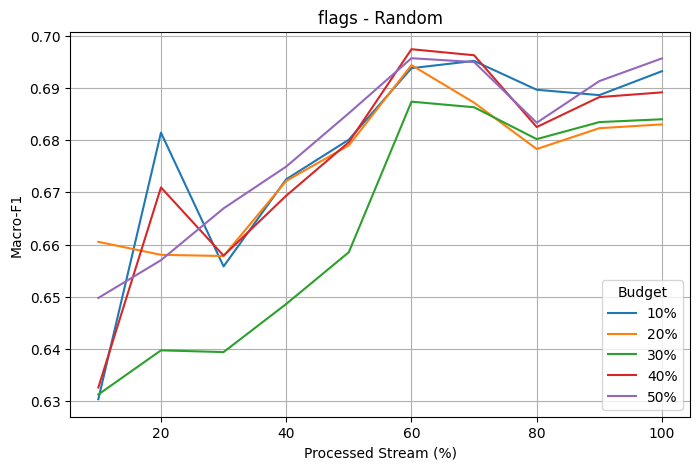

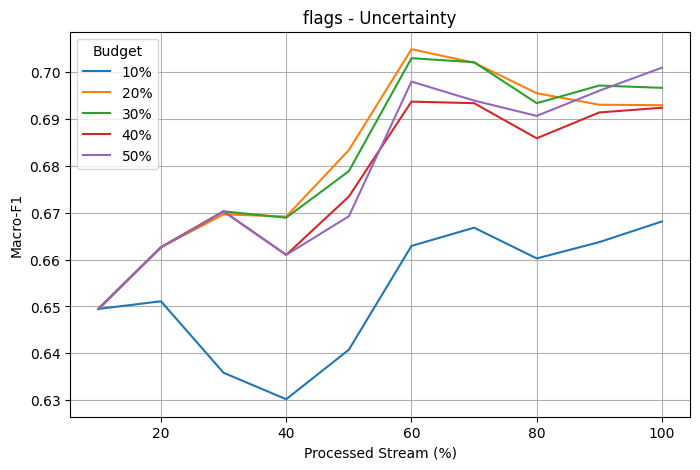

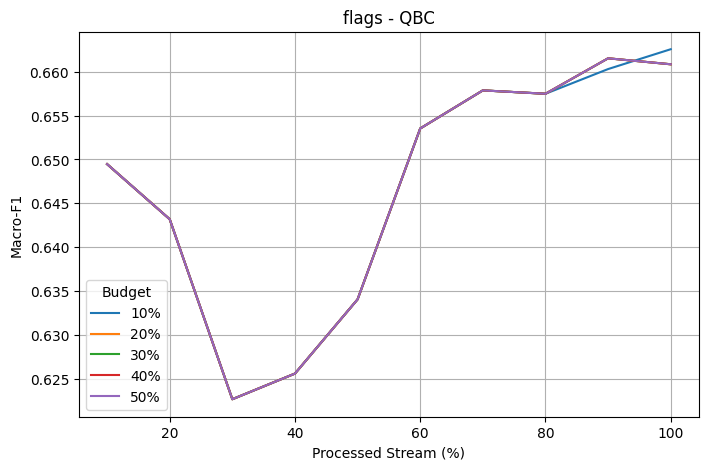

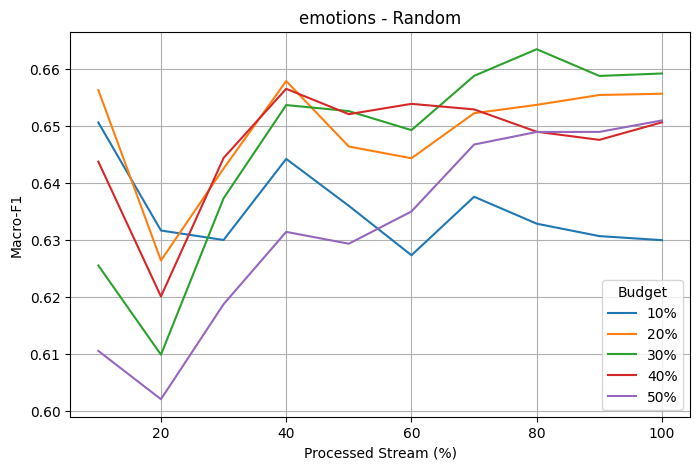

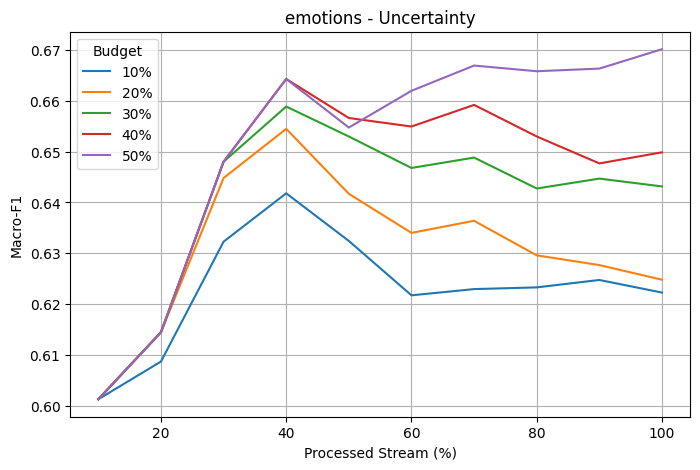

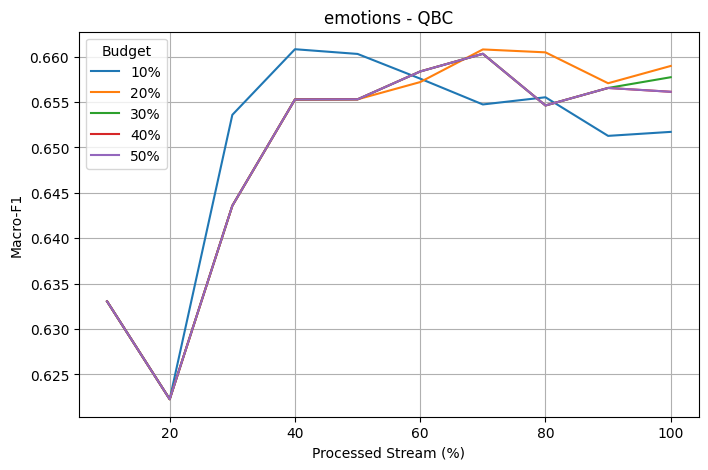

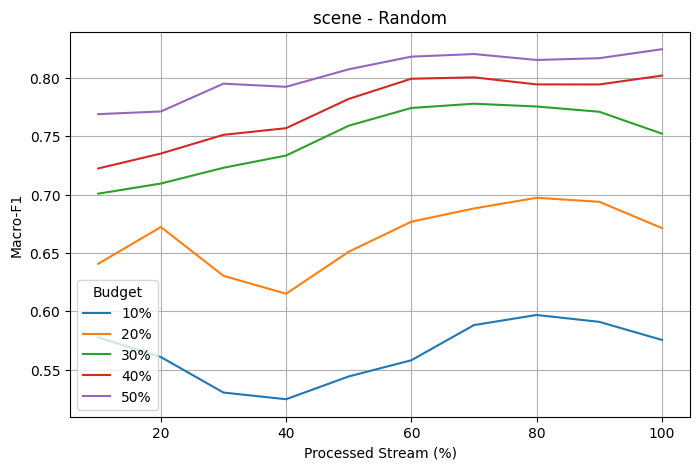

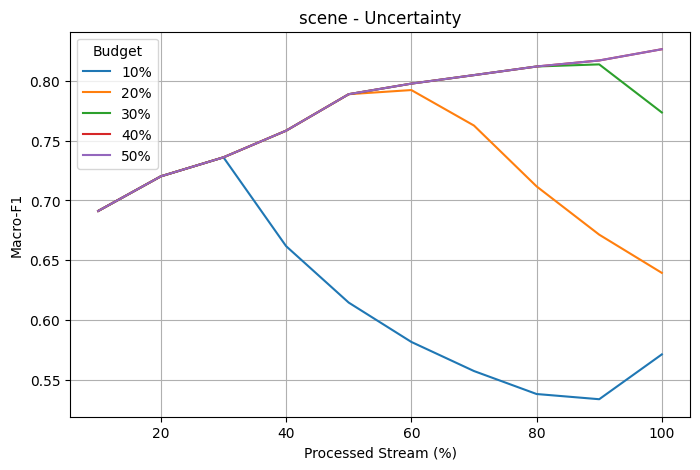

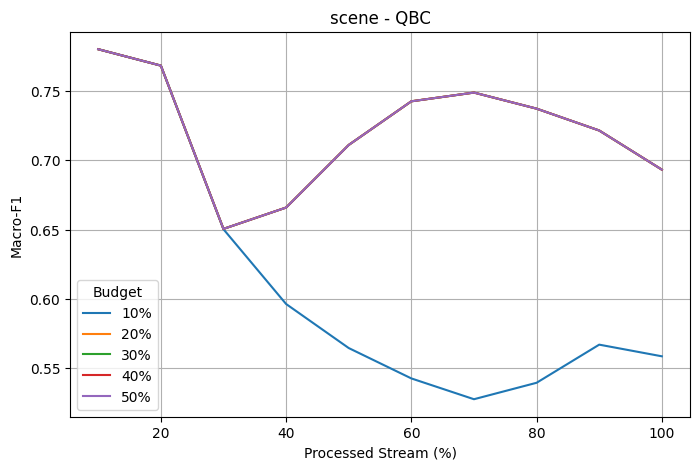

In [ ]:
budgets = [10, 20, 30, 40, 50]

for dataset_name in all_results.keys():

    for strategy in ["Random", "Uncertainty", "QBC"]:

        plt.figure(figsize=(8,5))

        for budget in budgets:

            key = f"{strategy}_{budget}%"

            hist = all_results[dataset_name][key]["History"]

            plt.plot(
                hist["progress"],
                hist["f1"],
                label=f"{budget}%"
            )

        plt.title(f"{dataset_name} - {strategy}")
        plt.xlabel("Processed Stream (%)")
        plt.ylabel("Macro-F1")
        plt.grid(True)
        plt.legend(title="Budget")

        plt.show()

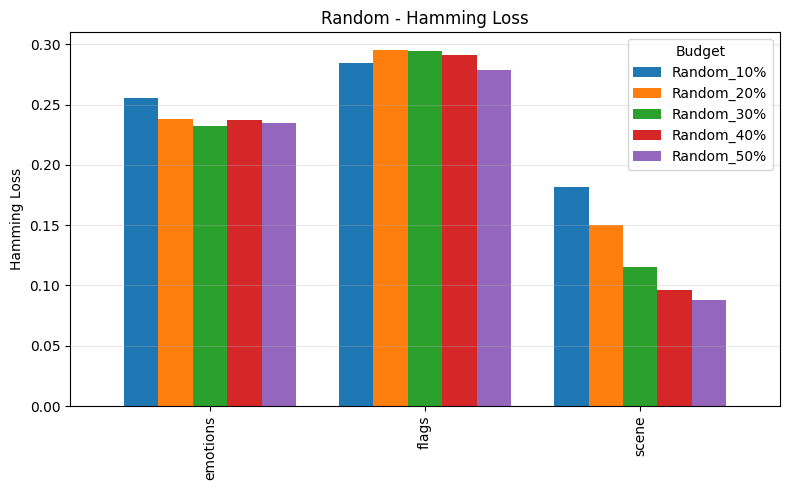

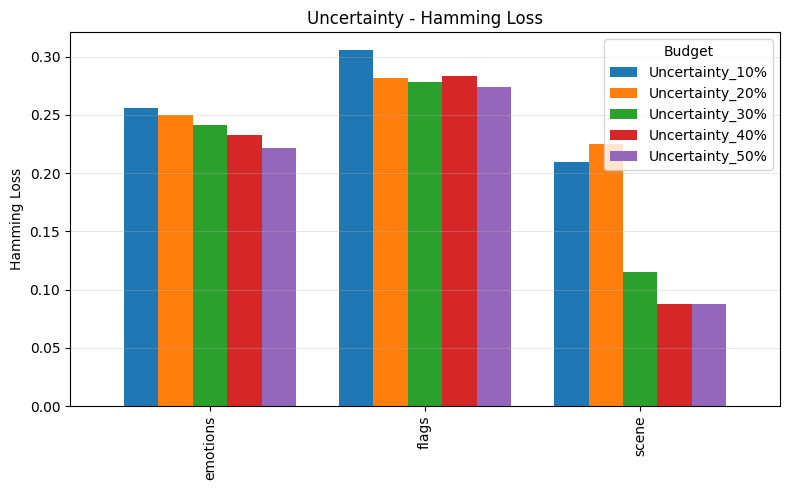

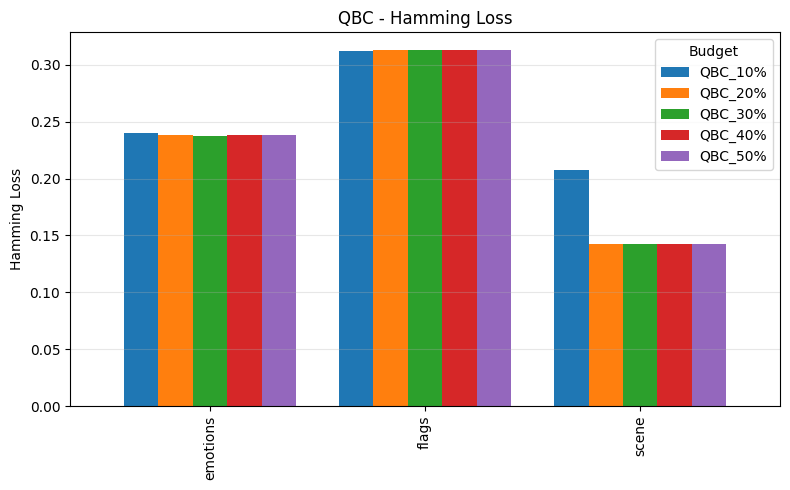

In [ ]:
budgets = [10, 20, 30, 40, 50]

for strategy in ["Random", "Uncertainty", "QBC"]:

    cols = [f"{strategy}_{b}%" for b in budgets]

    pivot = df_results.pivot(
        index="Dataset",
        columns="Strategy",
        values="Hamming Loss"
    )[cols]

    pivot.plot(
        kind="bar",
        figsize=(8,5),
        width=0.8
    )

    plt.title(f"{strategy} - Hamming Loss")
    plt.ylabel("Hamming Loss")
    plt.xlabel("")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Budget")
    plt.tight_layout()
    plt.show()

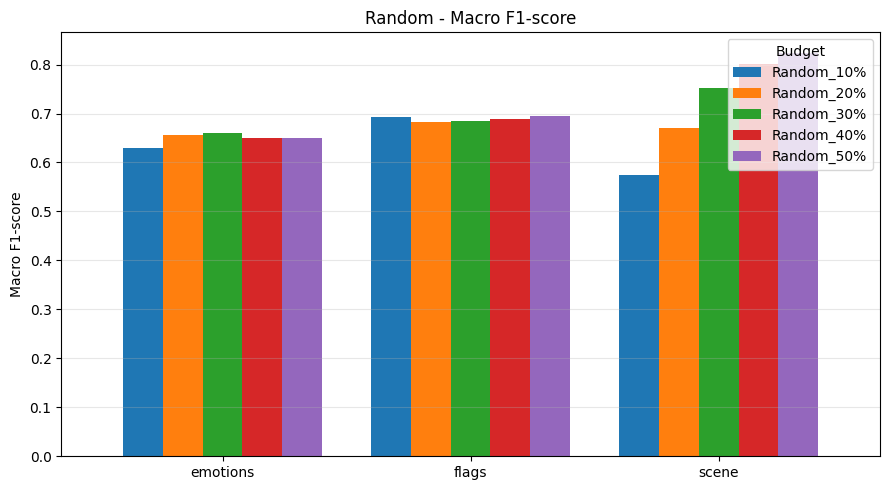

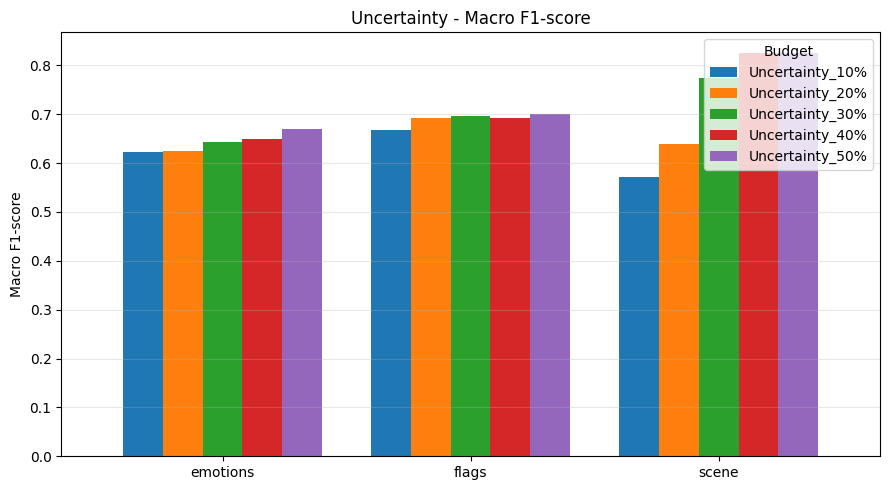

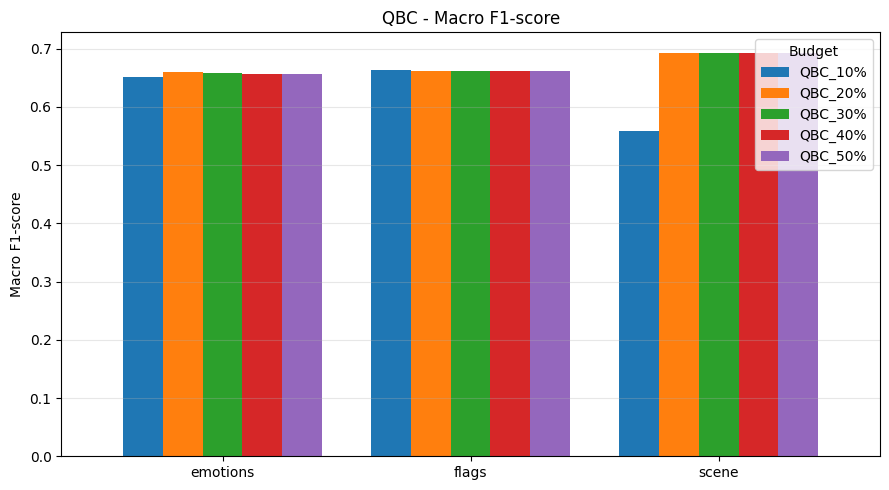

In [ ]:
budgets = [10, 20, 30, 40, 50]

for strategy in ["Random", "Uncertainty", "QBC"]:

    cols = [f"{strategy}_{b}%" for b in budgets]

    pivot_f1 = (
        df_results.pivot(
            index="Dataset",
            columns="Strategy",
            values="F1-score"
        )[cols]
    )

    ax = pivot_f1.plot(
        kind="bar",
        figsize=(9,5),
        width=0.8
    )

    ax.set_ylabel("Macro F1-score")
    ax.set_xlabel("")
    ax.set_title(f"{strategy} - Macro F1-score")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=0)
    plt.legend(title="Budget")
    plt.tight_layout()
    plt.show()

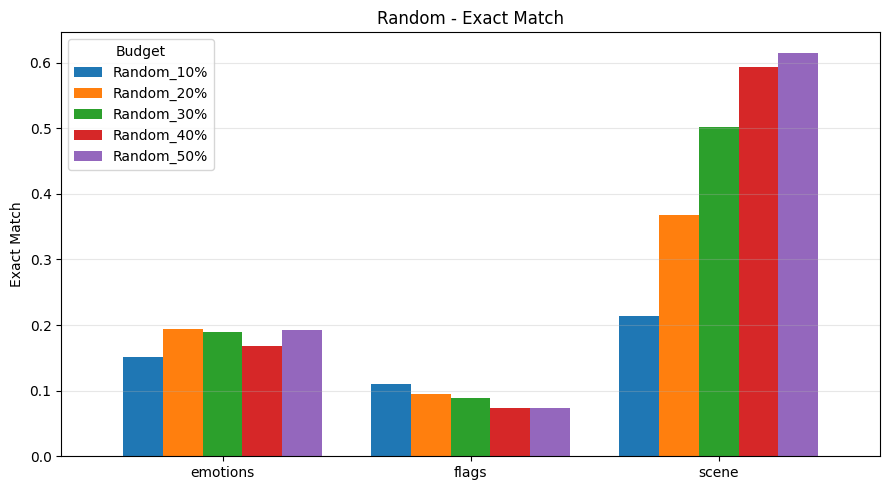

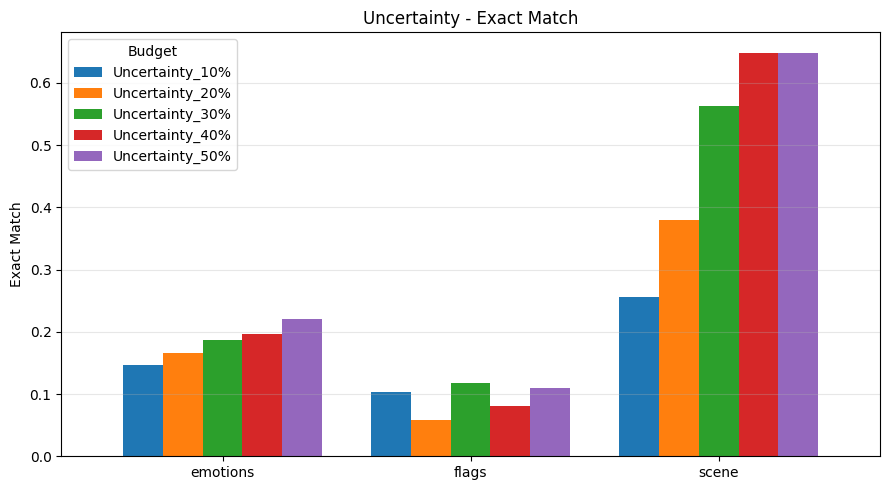

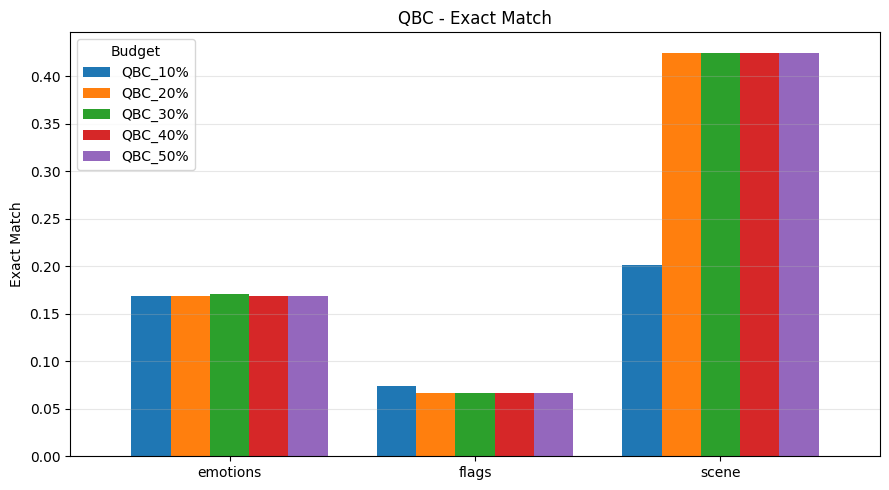

In [ ]:
budgets = [10, 20, 30, 40, 50]

for strategy in ["Random", "Uncertainty", "QBC"]:

    cols = [f"{strategy}_{b}%" for b in budgets]

    pivot_exact = (
        df_results.pivot(
            index="Dataset",
            columns="Strategy",
            values="Exact Match"
        )[cols]
    )

    ax = pivot_exact.plot(
        kind="bar",
        figsize=(9,5),
        width=0.8
    )

    ax.set_ylabel("Exact Match")
    ax.set_xlabel("")
    ax.set_title(f"{strategy} - Exact Match")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=0)
    plt.legend(title="Budget")
    plt.tight_layout()
    plt.show()

### Análise de drift com ADWIN

In [ ]:
for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        print(f"\nStrategy: {strategy_name}")
        print(f"Dataset: {dataset_name} -> Drifts detectados:", results["Number of Drifts"])


Strategy: NoQuery
Dataset: flags -> Drifts detectados: 0

Strategy: FullSupervision
Dataset: flags -> Drifts detectados: 0

Strategy: Random_10%
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty_10%
Dataset: flags -> Drifts detectados: 0

Strategy: QBC_10%
Dataset: flags -> Drifts detectados: 0

Strategy: Random_20%
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty_20%
Dataset: flags -> Drifts detectados: 0

Strategy: QBC_20%
Dataset: flags -> Drifts detectados: 0

Strategy: Random_30%
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty_30%
Dataset: flags -> Drifts detectados: 0

Strategy: QBC_30%
Dataset: flags -> Drifts detectados: 0

Strategy: Random_40%
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty_40%
Dataset: flags -> Drifts detectados: 0

Strategy: QBC_40%
Dataset: flags -> Drifts detectados: 0

Strategy: Random_50%
Dataset: flags -> Drifts detectados: 0

Strategy: Uncertainty_50%
Dataset: flags -> Drifts detectados: 0

Strategy

### Análise de consumo de memória e tempo de execução

In [ ]:
rows = []

for dataset_name, strategies_results in all_results.items():

    for strategy_name, results in strategies_results.items():

        rows.append({
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            "Execution Time (s)": results["Execution Time (s)"],
            "Memory Usage (MB)": results["Memory Usage (MB)"]
        })

df_results = pd.DataFrame(rows)

print(df_results)

     Dataset         Strategy  Execution Time (s)  Memory Usage (MB)
0      flags          NoQuery            0.817184           0.000000
1      flags  FullSupervision           17.944245         152.527344
2      flags       Random_10%            2.271683           0.000000
3      flags  Uncertainty_10%            1.907247           0.000000
4      flags          QBC_10%            2.893568           0.101562
5      flags       Random_20%            2.686249           0.000000
6      flags  Uncertainty_20%            3.890274           0.000000
7      flags          QBC_20%            4.071867           0.000000
8      flags       Random_30%            6.581692           0.011719
9      flags  Uncertainty_30%            6.395847           0.035156
10     flags          QBC_30%            4.772260           0.011719
11     flags       Random_40%            7.464793           0.000000
12     flags  Uncertainty_40%            7.759750           0.054688
13     flags          QBC_40%     

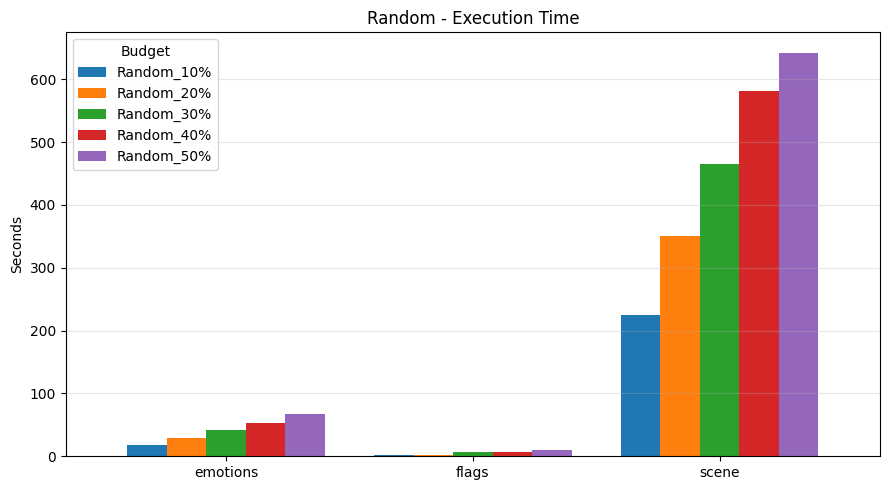

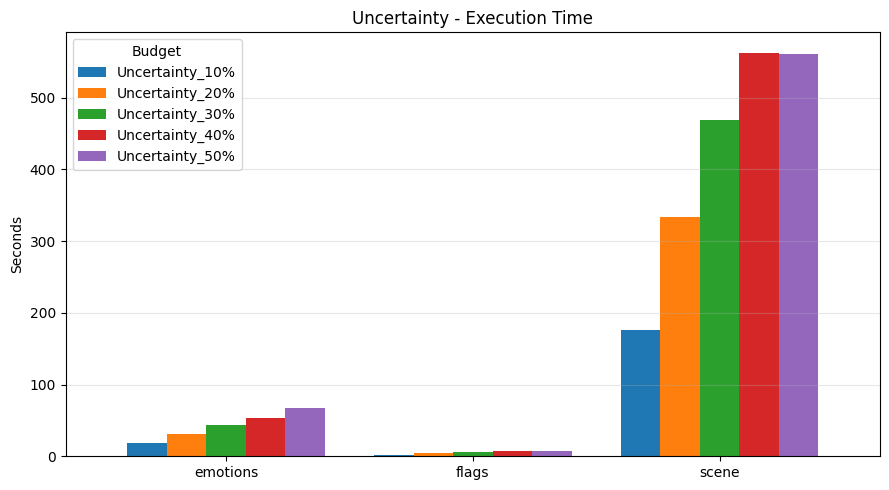

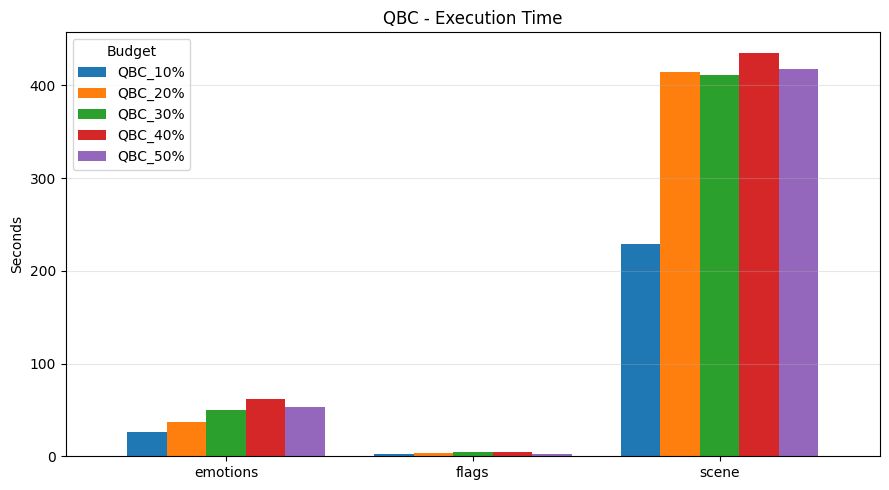

In [ ]:
budgets = [10, 20, 30, 40, 50]

for strategy in ["Random", "Uncertainty", "QBC"]:

    cols = [f"{strategy}_{b}%" for b in budgets]

    pivot_time = (
        df_results.pivot(
            index="Dataset",
            columns="Strategy",
            values="Execution Time (s)"
        )[cols]
    )

    ax = pivot_time.plot(
        kind="bar",
        figsize=(9,5),
        width=0.8
    )

    ax.set_title(f"{strategy} - Execution Time")
    ax.set_ylabel("Seconds")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=0)
    plt.legend(title="Budget")
    plt.tight_layout()
    plt.show()

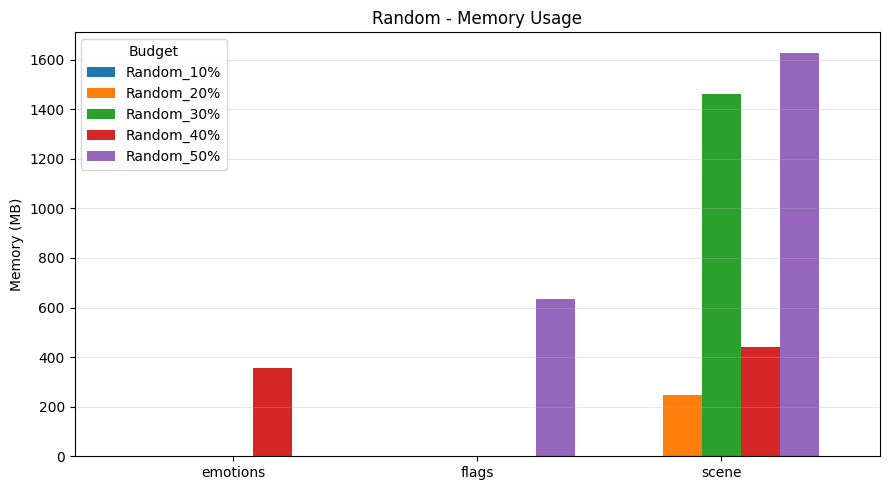

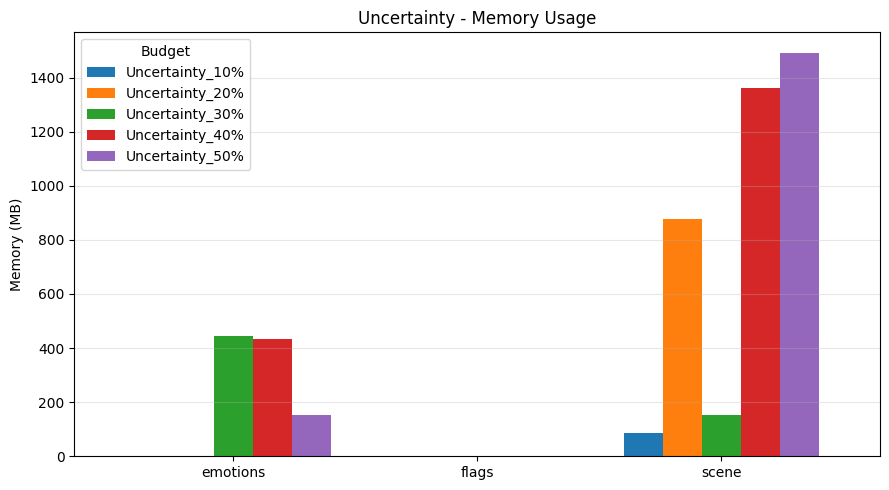

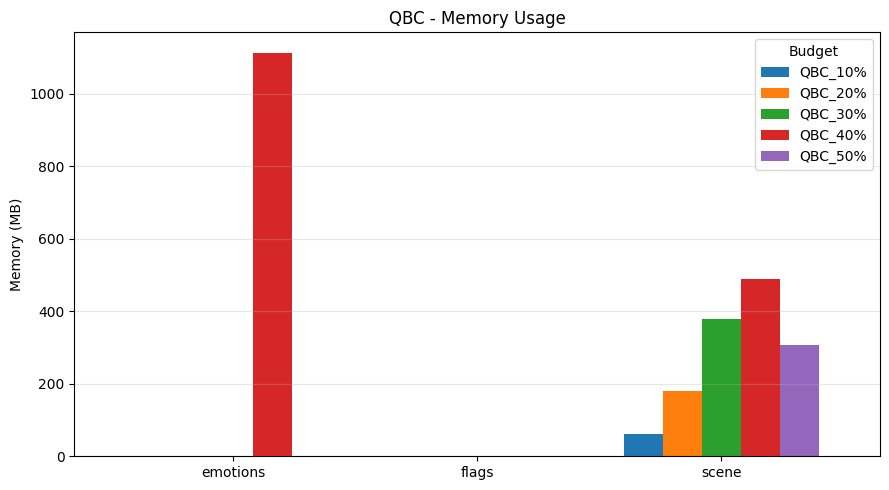

In [ ]:
budgets = [10, 20, 30, 40, 50]

for strategy in ["Random", "Uncertainty", "QBC"]:

    cols = [f"{strategy}_{b}%" for b in budgets]

    pivot_memory = (
        df_results.pivot(
            index="Dataset",
            columns="Strategy",
            values="Memory Usage (MB)"
        )[cols]
    )

    ax = pivot_memory.plot(
        kind="bar",
        figsize=(9,5),
        width=0.8
    )

    ax.set_title(f"{strategy} - Memory Usage")
    ax.set_ylabel("Memory (MB)")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=0)
    plt.legend(title="Budget")
    plt.tight_layout()
    plt.show()